# 평가
> 성능평가지표: 모델이 분류냐 회귀냐에 따라 여러 종류로 나뉨.
> 
> 회귀: 오차평균값에 기반
>
> 분류: 정확도, 오차행렬, 정밀도, 재현율, F1스코어, ROC AUC

## 정확도: 실제 데이터에서 예측 데이터가 얼마나 같은지
> 정확도= 예측 결과와 동일한 데이터 수 / 전체 데이터 수

In [1]:
from sklearn.base import BaseEstimator
#BaseEstimator는 Customized형태의 Estimator 를 개발자가 생성 가능
#MyDumyClassifier클래스: fit()는 수행x, predict()는 sex피처에만 반대로 예측하는 분류기
class MyDummyClassifier(BaseEstimator):
    def fit(self,X,y=None):
        pass
    def predict(self,X):
        pred=np.zeros((X.shape[0],1))
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i]==1:
                pred[i]=0
            else:
                pred[i]=1
        return pred

In [4]:
from sklearn.preprocessing import LabelEncoder
#transform_features 만들기

# Null 처리
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 불필요 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# transform_features 완성
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
#생성된 MyDummyClassifier로 타이타닉 생존자 예측 수행
titanic_df=pd.read_csv('./titanic_train.csv')
y_titanic_df=titanic_df['Survived']
X_titanic_df=titanic_df.drop('Survived',axis=1)
x_titanic_df=transform_features(X_titanic_df)
X_train,X_test,y_train,y_test=train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=0)

myclf=MyDummyClassifier()
myclf.fit(X_train,y_train)
mypredictions=myclf.predict(X_test)
print('Dummy Classifierdml 정확도는: {0:.4f}'.format(accuracy_score(y_test,mypredictions)))

Dummy Classifierdml 정확도는: 0.7877


C:\Users\YOON\AppData\Local\Temp\ipykernel_11780\6778363.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\YOON\AppData\Local\Temp\ipykernel_11780\6778363.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

>성별을 반대로 예측하는 예측 모델인데도 점수가 높게 나옴.
>
>불균형한 데이터에서 정확도는 좋은 평가 지표가 아님.
>
>올바른 평가 지표 선정 필요

### 0~9의 숫자 이미지 픽셀 정보를 갖고 있으며, 이를 기반으로 Digit을 예측하는데 사용되는 MNIST 데이터 세트를 불균형한 데이터 세트로 만든 뒤 정확도 지표 적용
>원래는 0부터 9까지 멀티 레이블 분류
>
>레이블 값이 7인 것만 True, 나머지는 False로 변환하는 이진분류로 변환
>
>이런 불균형 데이터 세트에 모든 데이터를 false, 0으로 예측하는 분류기 이용하여 정확도 측정 시 90%에 가까운 예측 정확도를 나타냄.
>
>특정 결과로 선택해도 데이터 분포가 높지 않은 경우 높은 수치가 나타날 수 있기 때문

In [7]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
    def fit(self,X,y):
        pass
    
    # 입력값으로 들어오는 X 데이터 셋의 크기만큼 모두 0값으로 만들어서 반환
    def predict(self,X):
        return np.zeros( (len(X), 1) , dtype=bool)

# 사이킷런의 내장 데이터 셋인 load_digits( )를 이용하여 MNIST 데이터 로딩
digits = load_digits()

# digits번호가 7번이면 True이고 이를 astype(int)로 1로 변환, 7번이 아니면 False이고 0으로 변환. 
y = (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split( digits.data, y, random_state=11)

In [8]:
#불균형한 레이블 데이터 분포도 확인
print('레이블 테스트 세트 크기:',y_test.shape)
print('테스트 세트 레이블 0과 1의 분포도')
print(pd.Series(y_test).value_counts())

#Dummy Classifier로 학습/예측/정확도 평가
fakeclf=MyFakeClassifier()
fakeclf.fit(X_train,y_train)
fakepred=fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test,fakepred)))

레이블 테스트 세트 크기: (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는:0.900


### 오차행렬(Confusion matrix, 혼동행렬)
: 이진 분류의 예측 오류가 얼마인지, 어떤 유형의 예측 오류가 발생하는지를 함께 나타냄
> 실제 클래스, 예측 클래스 0 1 에 따라 총 4개, TN FP FN TP로 분류
>
> 기호 앞 문자 T/F는 예측값과 실제값이 같은가/틀린가
>
> 뒤 문자 N/P는 예측 값이 부정/긍정
>
> confusion_matrix() API제공

In [10]:
#MyFakeClassifier 예측 결과인 fakepred와 실제 결과인 y_test를 
#confusion_matrix()의 인자로 입력해 오차 행렬 출력
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,fakepred)

array([[405,   0],
       [ 45,   0]])

>출력된 오차는 ndarray 형태, 이진 분류의 TN FP FN FP는 도표와 동일한 위치로 출력.
>
>앞절의 MyFakeClassifier는 target이 7인지 아닌지에 따라 예측 405건의 0(N), 45건의 1(P)
>
>따라서 TN은 450건 중 맞춘거 405개(TN), 틀린거 45개(FN)
>
>TN은 정확도의 기준에서 옳게 예측한 결괏값이기 때문에 잘못된 예측모델이라 할지라도 매우 적은 타겟에 1을 부여하는 불균형 데이터에서는 높은 정확도가 나오게 됨

### 정밀도와 재현율: Positive 예측 성능에 초점
> 정밀도: TP/ (FP + TP). 양성 예측도. Positive로 예측한 것들 중 맞은거. precision_score()
>
> 재현율: TP/ (FN + TP). 민감도, TPR. 실제값이 Positive인 것들 중 맞은거. recall_score()
>
> 재현율은 양성 데이터가 중요한 경우, 정밀도는 음성 데이터가 중요한 경우
>
> 둘은 보완적인 지표이며, 하나만 높고 다른 하나는 낮은 경우도 바람직하지 않음

In [11]:
#평가 지표들 한번에 꺼내는 함수 제작
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)

    print("오차 행렬")
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy, precision, recall))

In [13]:
#LogisticRegression의 생성 인자로 입력되는 solver='liblinear'는 로지스틱 회귀의 최적화 알고리즘 유형 지정
#보통 작은 데이터 세트의 이진 분류인 경우 solver는 liblinear가 약간 성능이 좋음
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 원본 데이터를 재로딩, 데이터 가공, 학습 데이터/테스트 데이터 분할
titanic_df = pd.read_csv('./titanic_train.csv')

y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df, y_titanic_df,
    test_size=0.20, random_state=11
)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
pred=lr_clf.predict(X_test)
get_clf_eval(y_test,pred)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


C:\Users\YOON\AppData\Local\Temp\ipykernel_11780\6778363.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\YOON\AppData\Local\Temp\ipykernel_11780\6778363.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

정밀도 또는 재현율이 특별히 강조돼야 할 경우 분류의 결정 임곗값 조정

but 둘은 상호 보완적인 지표이기 때문에 trade-off.

사이킷런의 분류 알고리즘은 예측 데이터가 특정 레이블에 속하는지를 계산하기 위해 레이블별 결정 확률을 구하고, 예측 확률이 큰 레이블값으로 예측함.

일반적으로 이진 분류에서는 임곗값을 50%로 하여 이것보다 크면 P, 작으면 N

개별 데이터 예측 확률 반환 메서드 predict_proba(). 학습이 완료된 분류기 객체에서 호출 가능.

테스트 피처 데이터 세트를 파라미터로 입력 시 테스트 피처 레코드의 개별 클래스 예측 확률 반환

predict_proba()에서 반환되는 ndarray는 첫 번째 칼럼이 클래스값 0에 대한 예측확률, 두 번째가 1에 대한 예측확률.

In [14]:
pred_proba = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)

print('pred_proba() 결과 Shape : {0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

# 예측 확률 array와 예측 결과값 array를 병합(concatenate)해 예측 확률과 결과값을 한눈에 확인
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis=1)
print('두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 \n', pred_proba_result[:3])

pred_proba() 결과 Shape : (179, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.44935227 0.55064773]
 [0.86335512 0.13664488]
 [0.86429645 0.13570355]]
두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 
 [[0.44935227 0.55064773 1.        ]
 [0.86335512 0.13664488 0.        ]
 [0.86429645 0.13570355 0.        ]]


In [15]:
#predict는 predict_proba가 반환하는 확률을 임곗값에 따라 최종값으로 바로 출력
#정밀도/재현율 trade-off 구현 by Binarizer클래스
from sklearn.preprocessing import Binarizer

X = [[1, -1, 2],
     [2, 0, 0],
     [0, 1.1, 1.2]]

#threshold 변수 설정, binarizer 클래스를 객체로 생성.
#fit_transform()을 통해 ndarray 입력 시 threshold에 따라 0/1로 반환
binarizer = Binarizer(threshold=1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [16]:
#binarizer를 이용해 predict()의 의사코드구현, 평가지표출력
from sklearn.preprocessing import Binarizer

# Binarizer의 threshold 설정값
custom_threshold = 0.5

# predict_proba() 반환값의 두 번째 칼럼,
#즉 Positive 클래스 칼럼 하나만 추출해 Binarizer를 적용
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


In [17]:
# 앞에서 predict()로 계산된 지표 값과 동일. predict가 predict_proba에서 기반함 확인

#임곗값 낮춰서 재시행
custom_threshold = 0.4

pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197


In [18]:
#임곗값을 낮추니 재현율이 올라가고 정밀도가 떨어짐 positive값이 많아졌기 때문

#임곗값을 높이면서 재시행
#테스트를 수행할 모든 임곗값을 리스트 객체로 저장
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    # thresholds list객체 내의 값을 차례로 iteration 하면서 evaluation 수행
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값:', custom_threshold)
        get_clf_eval(y_test, custom_predict)
get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1,1),thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213


In [19]:
#precision_recall_curve(): 실제 클래스값 y_true, positive 예측 확률 배열 probas_pred 입력받아 정밀도, 재현율 반환

#타이타닉 예측 모델의 임곗값별 정밀도와 재현율 계산.
#임곗값이 너무 많으므로 대신 15단계 임곗값으로 10개 샘플 추출
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일 때의 예측 확률 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

# 실제값 데이터 세트와 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1)
print('반환된 분류 결정 임곗값 배열의 Shape:', thresholds.shape)

# 반환된 임계값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15step으로 추출
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임곗값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값:', np.round(thresholds[thr_index], 2))

# 15 step단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임곗값별 정밀도:', np.round(precisions[thr_index], 3))
print('샘플 임곗값별 재현율:', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 Shape: (165,)
샘플 추출을 위한 임곗값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150]
샘플용 10개의 임곗값: [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임곗값별 정밀도: [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임곗값별 재현율: [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


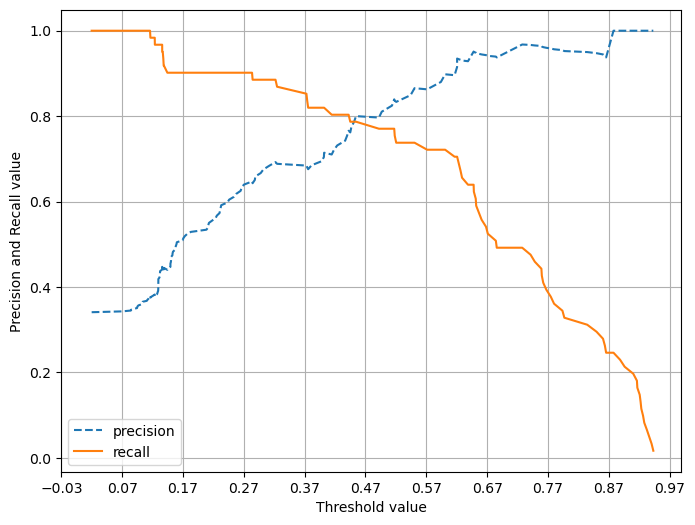

In [20]:
#임곗값 변화에 따른 정밀도와 재현율 값 변화를 그래프로 시각화
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
def precision_recall_curve_plot(y_test, pred_proba_c1):
    # threshold ndarray와 threshold에 따른 정밀도, 재현율 ndarray 추출
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)

    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary],linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')

    # threshold 값 X축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))

    # X축, Y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value')
    plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

precision_recall_curve_plot(y_test,lr_clf.predict_proba(X_test)[:, 1])

### F1 스코어: 정밀도와 재현율 결합
> F1= 2/{(1/재현율)+(1/정밀도)} = 2*(정밀도*재현율)/(정밀도+재현율)
>
> 정밀도와 재현율의 차이가 크면 F1 score가 낮아짐
>
> f1_score() API

In [21]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,pred)
print('F1 스코어: {0:.4f}'.format(f1))

F1 스코어: 0.7966


In [22]:
#임곗값 변화시키며 F1스코어 계산
def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    # F1 스코어 추가
    f1 = f1_score(y_test, pred)
    print('오차 행렬')
    print(confusion)
    #f1 score print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1:{3:.4f}'.format(accuracy, precision, recall, f1))

thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1:0.7576
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869, F1:0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1:0.7966
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377, F1:0.7965
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213, F1:0.8000


### ROC곡선과 AUC
>ROC곡선: 수신자 판단 곡선. 이진 분류 모델 예측 성능 판단
>
>FPR, False Positive Rate가 변할 때 재현율인 TPR, True Positive Rate가 어떻게 변하는지.
>
>x축 FPR, y축 TPR
>
>특이성, TNR= TN / (FP + TN)
>
>x축인 FPR= FP / (FP + TN) = 1 - TNR
>
>임곗값을 1로 하면 FPR이 0, TN을 0으로 하면 FPR이 1로 됨.
>
>roc_curve(): y_true, y_score 입력하여 fpr, tpr, thresholds 반환

In [23]:
from sklearn.metrics import roc_curve

# 레이블 값이 1일때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)

# 반환된 임곗값 배열에서 샘플로 데이터를 추출하되, 임곗값을 5 Step으로 추출.
# thresholds[0]은 max(예측확률)+1로 임의 설정됨. 이를 제외하기 위해 np.arange는 1부터 시작
thr_index = np.arange(1, thresholds.shape[0], 5)

print('샘플 추출을 위한 임곗값 배열의 index:', thr_index)
print('샘플 index로 추출한 임곗값:', np.round(thresholds[thr_index], 2))

# 5 step 단위로 추출된 임곗값에 따른 FPR, TPR 값
print('샘플 임곗값별 FPR:', np.round(fprs[thr_index], 3))
print('샘플 임곗값별 TPR:', np.round(tprs[thr_index], 3))

샘플 추출을 위한 임곗값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46]
샘플 index로 추출한 임곗값: [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
샘플 임곗값별 FPR: [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
샘플 임곗값별 TPR: [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


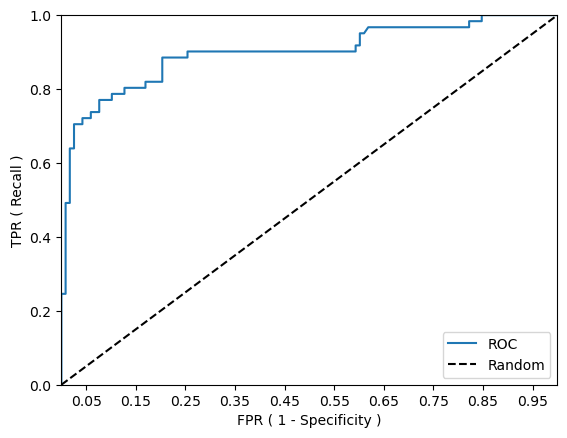

In [24]:
#임곗값이 1에 가까운 값에서 작아지면서 FPR이 점점 커짐.
#FPR이 커질 때 TPR은 가파르게 커짐
#FPR 변화에 따른 TPR 변화 시각화
def roc_curve_plot(y_test, pred_proba_c1):
    # 임곗값에 따른 FPR, TPR 값을 반환받음.
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)
    # ROC 곡선을 그래프 곡선으로 그림.
    plt.plot(fprs, tprs, label='ROC')
    # 가운데 대각선 직선을 그림.
    plt.plot([0, 1], [0, 1], 'k--', label='Random')

    # FPR X 축의 Scale을 0.1 단위로 변경, X, Y축 명 설정 등
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1);plt.ylim(0, 1)
    plt.xlabel('FPR ( 1 - Specificity )');plt.ylabel('TPR ( Recall )')
    plt.legend()
    
roc_curve_plot(y_test,pred_proba[:,1])

In [25]:
#분류의 성능 지표: ROC곡선 면적에 기반한 AUC(Area Under Curve).
#1에 가까울수록 좋은 수치. > FPR이 작은 상태에서 얼마나 큰 TPR을 얻을 수 있느냐.
#보통 0.5이상의 값을 가짐.
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.8987


In [26]:
#get_clf_eval()함수에 다 넣기
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    #ROC_AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, \
F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))